<a href="https://colab.research.google.com/github/AishaZAhmed/LLM-Fine-Tuning-For-Food-Hazard-Detection/blob/main/LLM_Fine_Tuning_for_Food_Hazard_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LLM Fine-Tuning for Food Hazard Detection**




Completed By: Aisha Ahmed \
Instructor: Dr. Zarrinkalam & Dr. Noughabi \
Project Completion: 2025-03-06\
Email: aahmed76@uoguelph.ca \
Student ID: 1336357

## Introduction
The goal of this project is to study the dataset introduced in the paper "SemEval-2025 Task 9: The Food Hazard Detection Challenge", fine-tune a training model, evaluate metrics and summarize results.

## Summary of SemEval-2025 Task 9: The Food Hazard Detection Challenge: (Extracts)

This is a challenge to produce text-based food hazard prediction with long tail distributed classes. This implementation could, for example, be used to help automated crawlers find and extract food issues from publicly available sources (e.g. social media). One major challenge posed in food-hazard and food-product classification from text is the large number of possible classes alongside a long-tail distribution. The dataset used in the challenge is a subset from English food recall announcements from the official websites of food agencies. The collection also includes information like the country of issue and the date of download. The majority of these texts were collected from US, Australian, Canadian, and UK-based domains between 2012 and 2022.



## 1. Dataset

○ dataset schema (columns)

1.	Year
2.	month	day
3.	title
4.	product
5.	product-category
6.	product-title
7.	hazard
8.	hazard-category
9.	hazard-title
10.	language
11.	country





**○ label spaces (how many unique hazard/product categories and values)**\
```
Number of unique hazard categories: 10
Hazard categories:
 ['biological' 'foreign bodies' 'chemical' 'fraud' 'organoleptic aspects'
 'allergens' 'packaging defect' 'other hazard'
 'food additives and flavourings' 'migration']

```
```
Number of unique product categories: 22
Product categories:
 ['meat, egg and dairy products' 'prepared dishes and snacks'
 'cereals and bakery products' 'confectionery' 'ices and desserts'
 'alcoholic beverages' 'fruits and vegetables'
 'other food product / mixed'
 'cocoa and cocoa preparations, coffee and tea'
 'nuts, nut products and seeds' 'seafood'
 'soups, broths, sauces and condiments' 'fats and oils'
 'non-alcoholic beverages' ':food contact materials'
 'dietetic foods, food supplements, fortified foods' 'herbs and spices'
 'food additives and flavourings' 'sugars and syrups'
 'honey and royal jelly' 'feed materials' 'pet feed']

```


**○ class imbalance observations (e.g., top-5 most frequent labels)**
```
Top 5 most frequent hazard categories:
hazard-category
biological        2020
allergens         1955
foreign bodies     769
chemical           498
fraud              411
```
```
Top 5 most frequent product categories:
product-category
meat, egg and dairy products    1687
cereals and bakery products      778
fruits and vegetables            655
prepared dishes and snacks       516
nuts, nut products and seeds     321
```
```
Rare product categories (<=10 examples):
product-category
honey and royal jelly    10
feed materials            6
sugars and syrups         5
```


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("food_recall_incidents v2.csv")

# 1. Label Space

# Unique hazard categories
hazard_categories = df["hazard-category"].dropna().unique() #df - dataframe
num_hazard_categories = len(hazard_categories)

# Unique product categories
product_categories = df["product-category"].dropna().unique()
num_product_categories = len(product_categories)

print("Number of unique hazard categories:", num_hazard_categories)
print("Hazard categories:\n", hazard_categories)

print("\nNumber of unique product categories:", num_product_categories)
print("Product categories:\n", product_categories)


# 2️. Class Imbalance (Hazards)

hazard_counts = df["hazard-category"].value_counts()

print("\nTop 5 most frequent hazard categories:")
print(hazard_counts.head(5))

print("\nRare hazard categories (<=10 examples):")
print(hazard_counts[hazard_counts <= 10])


# 3️. Class Imbalance (Products)

product_counts = df["product-category"].value_counts()

print("\nTop 5 most frequent product categories:")
print(product_counts.head(5))

print("\nRare product categories (<=10 examples):")
print(product_counts[product_counts <= 10])


Number of unique hazard categories: 10
Hazard categories:
 ['biological' 'foreign bodies' 'chemical' 'fraud' 'organoleptic aspects'
 'allergens' 'packaging defect' 'other hazard'
 'food additives and flavourings' 'migration']

Number of unique product categories: 22
Product categories:
 ['meat, egg and dairy products' 'prepared dishes and snacks'
 'cereals and bakery products' 'confectionery' 'ices and desserts'
 'alcoholic beverages' 'fruits and vegetables'
 'other food product / mixed'
 'cocoa and cocoa preparations, coffee and tea'
 'nuts, nut products and seeds' 'seafood'
 'soups, broths, sauces and condiments' 'fats and oils'
 'non-alcoholic beverages' 'food contact materials'
 'dietetic foods, food supplements, fortified foods' 'herbs and spices'
 'food additives and flavourings' 'sugars and syrups'
 'honey and royal jelly' 'feed materials' 'pet feed']

Top 5 most frequent hazard categories:
hazard-category
biological        2020
allergens         1955
foreign bodies     769
chem

## 2. LLM Fine-Tuning
○  Data preprocessing

  In the above code, Pandas open source library features such as .dropna() was used to remove missing values from a dataset by dropping the entire row.

In addition, the scikit-learn open source machine learning libray contains a function called LabelEncoder(), which was used to convert human-readable labels into integer class IDs. Scikit was also used for computing the evaluation metric (accuracy, macro F1, and micro F1).

Model training was conducted using the HuggingFace Transformers library (AI platform to easily discover and use models in Python) built on PyTorch (neural network computation).


○ Pretrained model

The pretrained model being used for this project is RoBERTa. RoBERTa is pretrained on: Wikipedia, Books, Web text, etc.


  What to expect when Fine-Tuning:

Before fine-tuning, the RoBERTa knows language, but not the specific classification of food hazard. Once a classification head is added and it is trained on chosen hazard labels, it will learn and adapt according to the task.


○ Fine-tune it on the training data

Please refer to the code below.


In [ ]:
!pip install transformers[torch] datasets accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Load Dataset
# ---------------------

df = pd.read_csv("food_recall_incidents v2.csv")

# Use hazard-category as label
df = df[["title", "hazard-category"]].dropna()

# Encode labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["hazard-category"])

num_labels = len(label_encoder.classes_)
print("Number of labels:", num_labels)

# Train/Validation split 80 training 20 validation
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

#Convert to HuggingFace Datase
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# Tokenization
# ---------------------
#tokenizer, translates text to numbers, token is a keyword
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer(
        example["title"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

#converts the internal format of a huggingface dataset into a PyTorch-compatible format
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load Model
# ---------------------

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# Metrics
# ---------------------

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1)

    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")
    micro_f1 = f1_score(labels, predictions, average="micro")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1
    }

# Training Arguments
# ---------------------

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5, #standard
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01, #prevents overfitting
    logging_dir="./logs",
    load_best_model_at_end=True,
)

# Trainer
# ---------------------

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# Train
# ---------------------

trainer.train()

# Evaluate
# ---------------------

results = trainer.evaluate()
print(results)

# Save Model
# ---------------------

model.save_pretrained("./fine_tuned_model")
tokenizer.save_pretrained("./fine_tuned_model")

print("Training complete and model saved.")

#producing the classification report
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(preds, predictions.label_ids))

Number of labels: 10


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 0.7387015223503113, 'eval_accuracy': 0.7644110275689223, 'eval_macro_f1': 0.41186756432118116, 'eval_micro_f1': 0.7644110275689223, 'eval_runtime': 9.3624, 'eval_samples_per_second': 127.852, 'eval_steps_per_second': 8.011, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete and model saved.
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       437
           1       0.90      0.77      0.83       477
           2       0.51      0.55      0.53        92
           3       0.00      0.00      0.00         0
           4       0.53      0.80      0.64       102
           5       0.62      0.81      0.70        63
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.41      0.48      0.44        25
           9       0.06      1.00      0.12         1

    accuracy                           0.76      1197
   macro avg       0.39      0.52      0.41      1197
weighted avg       0.82      0.76      0.78      1197



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


○ Report training details

**Steps to Train Model:**
1. Load dataset
2. Clean & encode labels
3. Split data
4. Tokenize text
5. Load pretrained model
6. Define metrics
7. Define training settings
8. Train
9. Evaluate
10. Save model

**Tools Used:**
1. HuggingFace - Model + training
2. Pytorch - Neural network computation
3. Scikit-learn - Data prep + evaluation metrics
4. Pandas - Data preprocessing


## 3) Evaluation

After training RoBERTa, the following results were achieved:
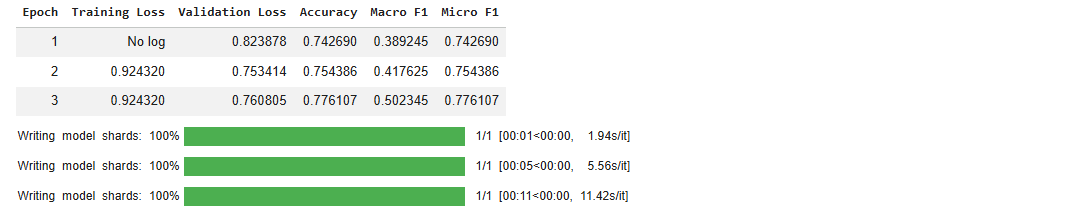

According to the table above, the Macro F1 score after 3 epoches (passes of the training dataset through our model) is **0.502345**. Similarly, the Mirco F1 score after 3 epoches is **0.776107**. The Accuracy of the model after 3 epoches is **0.776107**.


○ Per-class performance for the most frequent and rare labels


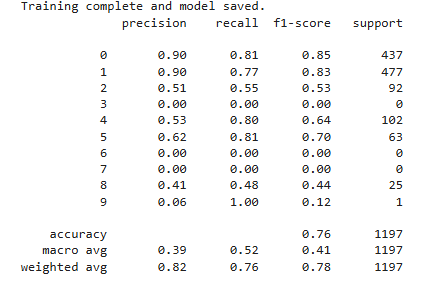

○ Short Failure Analysis

As mentioned previously, a challenge of detecting food hazards are that there are a large number of possible classes in its hazard and food classification. The dataset also follows a long-tail distribution, meaning there are various minority classes which skew the data. Moreover, class imbalance plays a role since the minority classes provide fewer inputs during training which results in the the model favoring the more frequent labels. Another source of error is latency that is produced by depending on external knowledge and limits real-time applicability.

To improve the training model, more data can be collected for uncommon classes or the entire data could be recollected. In addition, the model can run through more epoches to further fine-tune the model.



○ Key Observations

* Best performance is on the most frequent classes

  Referencing from the Per-class performance table, the best F1 scores are 0.85 and 0.83 on labels 0 and 1, which correspond to the first two labels "Allergens" and "Biological", also included in the top 10 hazard categories.

* RoBERTa's performance

  The pre-trained model RoBERTa, attained an accuracy of around 0.77, indicating that the model is able to predict the food hazard in many cases. It is also a decent score in comparison to some of the models observed in "SemEval-2025 Task 9: The Food Hazard Detection Challenge."

* Class imbalance

  There is an observable class imbalance in the dataset. Some labels are very common, while some are rare. The top 5 labels make up a significant percent of the collection, while the rare ones have only a few samples. Hence, this imbalance makes it difficult for the model to identify the underrepresented classes.


## Conclusion

In this project, I was required to tackle a real-world, safety-relevant NLP problem: food hazard detection. I used a RoBERTa model and fine-tuned it to identify categories such as the product category, product, hazard category, and hazard. The model successfully produced an approximate accuracy of 0.77, demonstrating the model's strong performance. Nonetheless, rare hazard categories were sometimes difficult for the model to correctly classify due to the lack of examples. All in all, this project gave me an in-depth introduction of LLMs and provided me with practical experience in research, analyzing data-sets, training, and reporting results.  

## Additional Learning

**What is the F1 score?**

The F1 score combines two metrics: Precision and recall into a single value.

Precision measures the accuracy of positive predictions. \
Recall measures the ability to find all actual positives.\
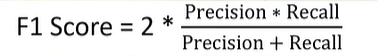


**Tokenization Vs. Label Encoding**

Label encoding: assigns a unique integer value to each distinct category in a dataset, transforming textual labels into a single numerical column.

 (e.g., "Small"=0, "Medium"=1, "Large"=2).

Tokenization: Textual/NLP Data
Tokenization splits raw text into small 'tokens' that can be processed by language models.

E.g.
Splitting by spaces and punctuation ("The cat" -> ["The", "cat"]).

Source: Google

**Long Tail Distribution**\
A long-tail distribution is where a large "head" of common events is followed by a "long tail" of uncommon, rare, or extreme events.
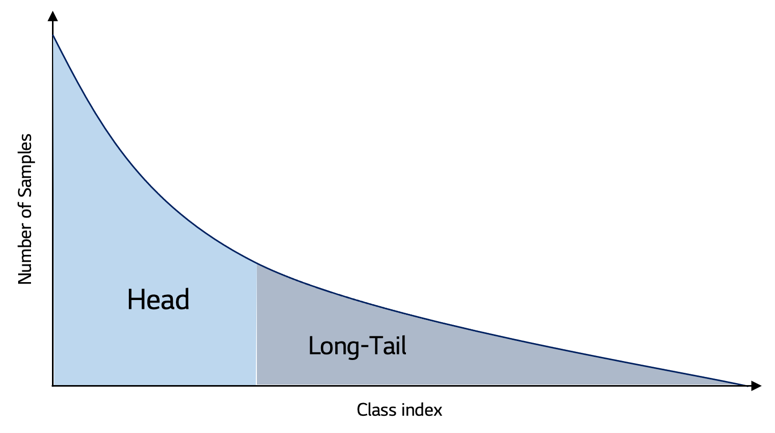

Source: lgresearch

**Class Imbalance**\
Class imbalance occurs when one class in a classification problem is the majority and heavily outweighs another class. \
Source: Medium - Class Imbalance Strategies — A Visual Guide with Code


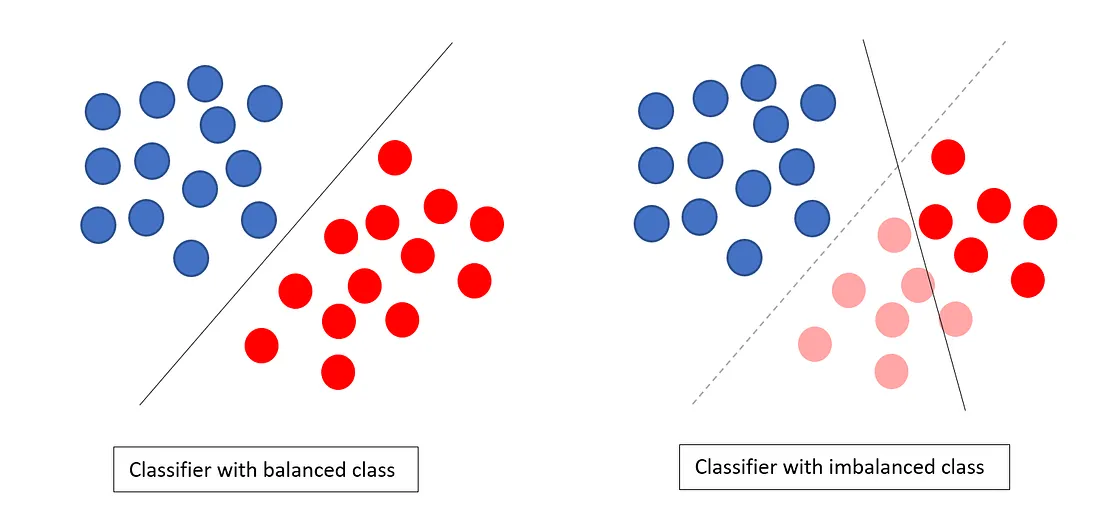

Source: Medium - Solving Class Imbalance problem in CNN

**Neural Networking**

Artificial Neural Networks are computer systems that imitate how human brains think, process information and make decisions. Artificial neurons are used to analyze data, find patternsand make predictions.

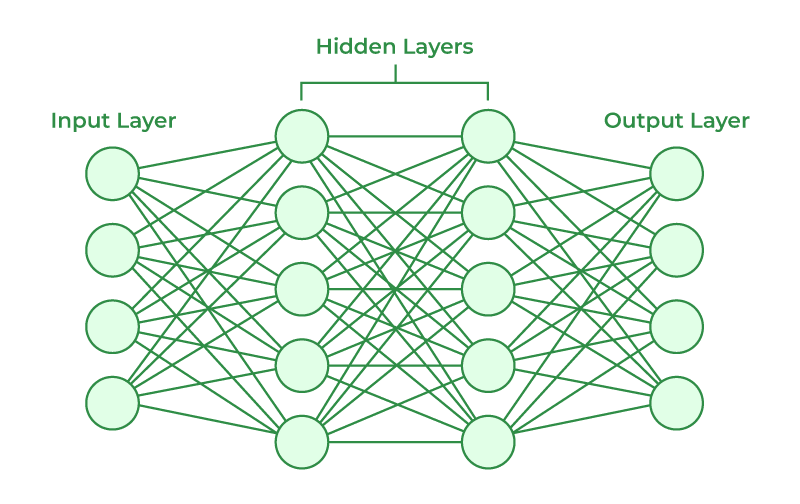

Source: Geeks For Geeks - Artificial Neural Networks and its Applications


##Other Resources


```
Build your first machine learning model in Python
https://www.youtube.com/watch?v=29ZQ3TDGgRQ&t=1104s
```
```
Simple Machine Learning Code Tutorial for Beginners with Sklearn Scikit-Learn
https://www.youtube.com/watch?v=-IvNzmrcyUM&t=1047s
```
```
Building a basic machine learning model in Python
https://towardsdatascience.com/building-a-basic-machine-learning-model-in-python-d7cca929ee62/
```
```
Part 1: Long-Tail Distribution Learning
https://www.lgresearch.ai/blog/view/?seq=257&page=1&pageSize=12
```
```
How to Use GOOGLE COLAB | Google Colab Tutorials for Beginners | GeeksforGeeks
https://www.youtube.com/watch?v=TqqkZLHoY0o
```
```
RoBERTa base model
https://huggingface.co/FacebookAI/roberta-base
```
```
Artificial Neural Networks and its Applications
https://www.geeksforgeeks.org/deep-learning/artificial-neural-networks-and-its-applications/
```